# Exploratory Data Analysis of Default Dataset

## Basic libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from pathlib import Path

DATA_DIR = Path().resolve().parent.parent / 'data' / 'data-09-2025'
merged_df = pd.read_csv(DATA_DIR / 'merged_df.csv')
merged_df.head()

,Unnamed: 0,n.credito,cartera,plazo,vinculacion,v.cuota,v.prestamo,s.capital,s.intereses,aportes,...,curtotalingresos,curtotalegresos,intestrato,actualización,default,puntaje_data,grupo_dptmto,grupo_ciudad,grupo_edad,grupo_actividadeco
0,0,003-002-0125852-7,consumo_sin_libranza,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,...,4597000.0,1500000.0,5.0,1,0,795.0,3,1,3,4
1,1,004-002-0068475-5,consumo_sin_libranza,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,...,4597000.0,650000.0,5.0,1,0,836.0,3,5,3,4
2,2,003-002-0122592-9,consumo_sin_libranza,1826,573,791482.0,30000000.0,23844684.0,261477,530431,...,4400000.0,2000000.0,4.0,0,1,709.0,3,7,2,4
3,3,006-002-0023879-0,consumo_sin_libranza,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,...,22020000.0,1500000.0,4.0,1,0,733.0,3,6,3,1
4,4,006-002-0026159-4,consumo_sin_libranza,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,...,22020000.0,1500000.0,4.0,1,0,695.0,3,6,3,1


In [3]:
merged_df = merged_df[merged_df["cartera"] != "vivienda"]

merged_df.reset_index(drop=True, inplace=True)

merged_df = merged_df.rename(columns={"actualización": "actualizacion"})
merged_df = merged_df.drop(
	columns=[
		"morosidad",
		"Unnamed: 0",
		"cartera",
		"grupo_dptmto",
		"grupo_ciudad",
		"grupo_edad",
		"grupo_actividadeco",
	],
	axis=1,
)
merged_df.columns = merged_df.columns.str.replace(".", "_", regex=False)
merged_df.columns = merged_df.columns.str.replace(":", "_", regex=False)
merged_df.columns = merged_df.columns.str.replace(" ", "_", regex=False)
merged_df.set_index("n_credito", inplace=True)

In [18]:
merged_df.describe()

,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,reestr,...,edad,tipoasociado,estado_cliente,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data
count,12861.000000,12861.000000,1.286100e+04,1.286100e+04,1.286100e+04,1.286100e+04,1.286100e+04,12861.000000,1.286100e+04,12861.000000,...,12861.000000,12861.000000,12861.000000,12861.000000,1.286100e+04,1.286100e+04,12861.000000,12861.000000,12861.000000,12861.000000
mean,1408.604463,2344.519866,4.439770e+05,1.605923e+07,1.113719e+07,2.459687e+05,1.681967e+06,1.749786,1.747395e+07,3.999689,...,40.892077,0.551435,1.009875,0.465671,3.710424e+06,1.048782e+06,2.606407,0.538294,0.173315,735.144468
std,618.441174,2160.510012,1.932434e+06,4.443301e+07,3.669858e+07,1.325304e+06,2.331709e+06,2.318343,3.128938e+08,0.024940,...,12.341556,0.497367,0.122743,0.498840,1.098662e+07,1.337498e+07,0.921137,0.498551,0.378534,93.989466
min,123.000000,61.000000,3.661700e+04,4.320000e+05,2.000000e+01,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,2.000000,...,19.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,304.000000
25%,1096.000000,779.000000,1.899200e+05,5.000000e+06,2.547476e+06,1.902500e+04,3.815110e+05,1.000000,5.100070e+05,4.000000,...,31.000000,0.000000,1.000000,0.000000,1.367549e+06,4.000000e+05,2.000000,0.000000,0.000000,704.000000
50%,1096.000000,1764.000000,2.875170e+05,9.100000e+06,5.399008e+06,6.484000e+04,9.400180e+05,1.000000,1.267765e+06,4.000000,...,39.000000,1.000000,1.000000,0.000000,1.991115e+06,5.874000e+05,3.000000,1.000000,0.000000,757.000000
75%,1826.000000,3267.000000,4.367740e+05,1.617000e+07,1.134539e+07,1.820620e+05,2.136749e+06,1.000000,2.762960e+06,4.000000,...,49.000000,1.000000,1.000000,1.000000,3.262786e+06,9.000000e+05,3.000000,1.000000,0.000000,798.000000
max,7720.000000,22267.000000,1.671000e+08,1.950000e+09,1.581029e+09,8.371030e+07,5.434683e+07,9.000000,1.426552e+10,4.000000,...,90.000000,1.000000,4.000000,1.000000,4.000000e+08,1.501600e+09,6.000000,1.000000,1.000000,850.000000


In [19]:
merged_df.describe(include='object')

,actividadeconomica,departamento,ciudad
count,12852,12860,12855
unique,176,23,285
top,asalariados,antioquia,medellin
freq,11454,12644,2886


In [20]:
merged_df.default.value_counts()

default
0    10632
1     2229
Name: count, dtype: int64

In [34]:
merged_df.head()

,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,reestr,...,estado_cliente,departamento,ciudad,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data
n_credito,,,,,,,,,,,,,,,,,,,,,
003-002-0125852-7,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,1,7741255,4,...,1,antioquia,bolivariana,0,4597000.0,1500000.0,5.0,1,0,795.0
004-002-0068475-5,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,1,4601706,4,...,1,antioquia,envigado,0,4597000.0,650000.0,5.0,1,0,836.0
003-002-0122592-9,1826,573,791482.0,30000000.0,23844684.0,261477,530431,1,530431,4,...,1,antioquia,medellin,0,4400000.0,2000000.0,4.0,0,1,709.0
006-002-0023879-0,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,2,320385440,4,...,1,antioquia,rionegro,0,22020000.0,1500000.0,4.0,1,0,733.0
006-002-0026159-4,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,2,320385440,4,...,1,antioquia,rionegro,0,22020000.0,1500000.0,4.0,1,0,695.0


In [35]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12861 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   plazo               12861 non-null  int64  
 1   vinculacion         12861 non-null  int64  
 2   v_cuota             12861 non-null  float64
 3   v_prestamo          12861 non-null  float64
 4   s_capital           12861 non-null  float64
 5   s_intereses         12861 non-null  int64  
 6   aportes             12861 non-null  int64  
 7   garantias           12861 non-null  int64  
 8   valorgarantia       12861 non-null  int64  
 9   reestr              12861 non-null  int64  
 10  ctasahorros         12861 non-null  float64
 11  edad                12861 non-null  float64
 12  tipoasociado        12861 non-null  int64  
 13  actividadeconomica  12852 non-null  object 
 14  estado_cliente      12861 non-null  int64  
 15  departamento        12860 non-

In [36]:
# Guardar merged_df limpio en formato Parquet

merged_df.to_parquet(DATA_DIR / 'data_default_clean.parquet', index=True)

For assembly models, all available features will be used, including text strings, and no preprocessing, null data management, or categorical variable encoding will be performed.

In [21]:
X = merged_df.drop('default', axis=1)

# The type of categorical variables is changed to ‘category’ so that the models 
# can handle them correctly.
categorical_features = X.select_dtypes(include='object').columns.to_list()
X[categorical_features] = X[categorical_features].astype('category')

y = merged_df['default']

# We separate the data into training and testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=y, 
    random_state=1
    )

# Pipelines with Skrub

### Light GBM model with tabular pipeline skrub without hyperparameter tuning

In [22]:
#Crear un modelo LightGBM con los mejores hiperparámetros encontrados
lgb_model_best = LGBMClassifier(
    objective='binary', # Objetivo de clasificación binaria
    class_weight='balanced', # Hace balanceo de clases
    colsample_bytree= 0.9005463006833063,
    learning_rate= 0.12023779811254239,
    max_depth= 10,
    min_child_samples= 39, 
    n_estimators= 105,
    num_leaves= 64,
    reg_alpha= 0.096,
    reg_lambda= 0.003019661310620262,
    scale_pos_weight= 2.007887722293911,
    subsample= 0.7707980192130739,
    verbose=0,
    )

# 1. Crear el learner
model_skrub = tabular_pipeline(lgb_model_best)

# 2. Entrenar el modelo
model_skrub.fit(X_train, y_train)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

,steps,"[('tablevectorizer', ...), ('squashingscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncod...ding='spline')
,specific_transformers,()
,drop_null_fraction,1.0


In [26]:
print(
    classification_report(
        y_test, 
        model_skrub.predict(X_test), 
        target_names=['No default', 'Default']
        )
    )

              precision    recall  f1-score   support

  No default       0.96      0.95      0.95      2127
     Default       0.78      0.80      0.79       446

    accuracy                           0.93      2573
   macro avg       0.87      0.88      0.87      2573
weighted avg       0.93      0.93      0.93      2573



c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\jhquiza\repos\proyecto-riesgos\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


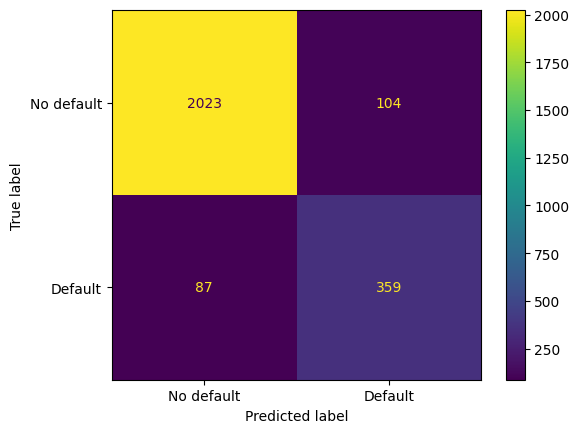

In [27]:
ConfusionMatrixDisplay.from_estimator(
    model_skrub, 
    X_test, 
    y_test,
    display_labels=['No default', 'Default']
    )

### Pipeline with Skrub table vectorizer, LGBM model, and hyperparameter tuning

In [28]:
warnings.filterwarnings('ignore')

pipe = Pipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("clf", LGBMClassifier(objective="binary", random_state=42))
])

param_distributions = {
    'clf__num_leaves': randint(20, 150),
    'clf__max_depth': randint(3, 15),
    'clf__learning_rate': loguniform(0.01, 0.3),
    'clf__n_estimators': randint(50, 500),
    'clf__min_child_samples': randint(2, 50),
    'clf__subsample': uniform(0.5, 0.5),  # de 0.5 a 1.0
    'clf__colsample_bytree': uniform(0.5, 0.5),
    'clf__eg_alpha': loguniform(1e-3, 10),
    'clf__reg_lambda': loguniform(1e-3, 10),
    'clf__scale_pos_weight': uniform(1, 10)  #Hiperparámetro para balancear clases
}

grid_search = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=20,
                                 scoring='f1_weighted')
grid_search.fit(
    X_train,
    y_train
    )

test_score = f1_score(y_test, grid_search.predict(X_test), average='weighted')
print(f'Best score: {grid_search.best_score_:.3f} with {grid_search.best_params_}')
print(f'Test score: {test_score:.3f}')

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [29]:
print(classification_report(y_test, grid_search.predict(X_test)))

[LightGBM] [Warning] Unknown parameter: eg_alpha
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2127
           1       0.84      0.76      0.80       446

    accuracy                           0.93      2573
   macro avg       0.90      0.87      0.88      2573
weighted avg       0.93      0.93      0.93      2573



[LightGBM] [Warning] Unknown parameter: eg_alpha


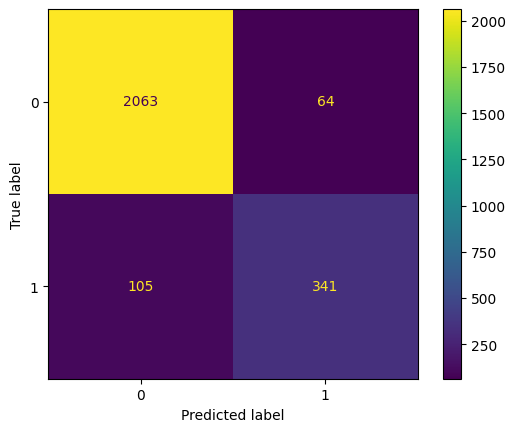

In [30]:
ConfusionMatrixDisplay.from_estimator(grid_search,X_test, y_test)

This is the model with the best performance

In [32]:
MODELS_DIR = Path().resolve().parent / 'models'

best_skrub=grid_search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "lgb_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\lgb_model.joblib']

In [ ]:
# Guardar hiperparámetros del modelo en en un archivo JSON
import json

with open(MODELS_DIR / "lgb_model_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)

### Skrub con modelo por defecto y ajuste de hiperparametros

In [37]:

# 1) Crea el pipeline por defecto (TableVectorizer + HistGradientBoostingClassifier)
pipe = tabular_pipeline("classifier")

# (Opcional) inspecciona qué parámetros puedes tunear
# print(pipe.get_params().keys())

# 2) Define el espacio de búsqueda
param_grid = {
    # --- TableVectorizer ---
    #"tablevectorizer__low_cardinality": [
    #    OneHotEncoder(handle_unknown="ignore"), 
    #    OrdinalEncoder()
    #],
    #"tablevectorizer__high_cardinality": [
    #    GapEncoder(n_components=10),
    #    "passthrough"  # o podrías usar hashing si lo defines manualmente
    #],
    #"tablevectorizer__cardinality_threshold":   [20, 50, 100],
    
    # --- HistGradientBoostingClassifier ---
    "histgradientboostingclassifier__learning_rate":   [0.1, 0.05, 0.02],
    "histgradientboostingclassifier__max_iter":        [200, 400, 800],
    "histgradientboostingclassifier__max_leaf_nodes":  [31, 63, 127],
    "histgradientboostingclassifier__min_samples_leaf":[10, 20, 40],
    "histgradientboostingclassifier__l2_regularization":[0.0, 0.1, 1.0],
    "histgradientboostingclassifier__early_stopping":  [True],
}

# 3) Métrica y CV (para 5 clases sueles preferir f1_macro)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average="macro")

# 4) Grid search
search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

search.fit(X_train, y_train)
best_pipe = search.best_estimator_

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor f1_macro (CV):", search.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores hiperparámetros: {'histgradientboostingclassifier__early_stopping': True, 'histgradientboostingclassifier__l2_regularization': 0.1, 'histgradientboostingclassifier__learning_rate': 0.05, 'histgradientboostingclassifier__max_iter': 200, 'histgradientboostingclassifier__max_leaf_nodes': 31, 'histgradientboostingclassifier__min_samples_leaf': 20}
Mejor f1_macro (CV): 0.870444617700642


In [39]:
# 5) Evaluación en test

y_pred = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2127
           1       0.84      0.69      0.76       446

    accuracy                           0.92      2573
   macro avg       0.89      0.83      0.86      2573
weighted avg       0.92      0.92      0.92      2573



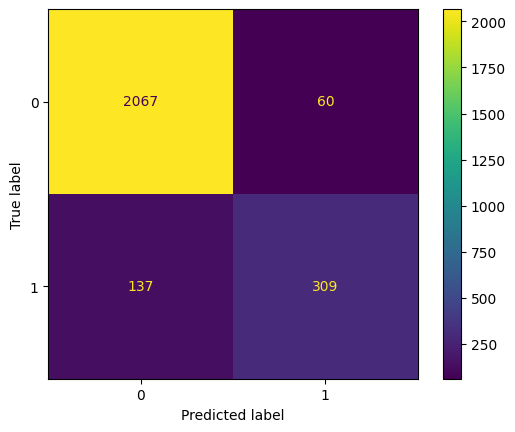

In [40]:
ConfusionMatrixDisplay.from_estimator(best_pipe,X_test, y_test)

In [44]:
best_skrub=search.best_estimator_
joblib.dump(best_skrub, MODELS_DIR / "hist_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\hist_model.joblib']

In [43]:
with open(MODELS_DIR / "hist_model_params.json", "w") as f:
    json.dump(search.best_params_, f, indent=4)

# Skrub with other models

## Skrub + xgbost

In [45]:
warnings.filterwarnings('ignore')
model_xgb = XGBClassifier(
    grow_policy='lossguide',
    tree_method='hist',
    enable_categorical=True # Allows categorical variables to be handled directly

    )

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("clf", model_xgb)
])

# This is the list of hyperparameters to tune
param_distributions = {
    'clf__max_depth': randint(3, 15),
    'clf__learning_rate': loguniform(0.01, 0.3),
    'clf__n_estimators': randint(1,500),
    'clf__subsample': uniform(0.5, 0.5),  # de 0.5 a 1.0
    'clf__colsample_bytree': uniform(0.5, 0.5),
    'clf__reg_alpha': loguniform(1e-3, 10),
    'clf__reg_lambda': loguniform(1e-3, 10),
    'clf__max_delta_step':randint(0,10),
    'clf__gamma':uniform(0,2),
    'clf__min_child_weight':randint(5,10),
    'clf__scale_pos_weight': uniform(1, 10)  # Con este hiperparámetro se balancean las clases
}

grid_search_xgb = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=50,
                                 scoring='f1_weighted',
                                 )
grid_search_xgb.fit(X_train,
                y_train,
                
                )

test_score = f1_score(y_test, grid_search_xgb.predict(X_test), average='weighted')
print(f'Best score: {grid_search_xgb.best_score_:.3f} with {grid_search_xgb.best_params_}')
print(f'Test score: {test_score:.3f}')

Best score: 0.929 with {'clf__colsample_bytree': np.float64(0.5041048801549949), 'clf__gamma': np.float64(0.848180954683738), 'clf__learning_rate': np.float64(0.019497829212420246), 'clf__max_delta_step': 6, 'clf__max_depth': 7, 'clf__min_child_weight': 7, 'clf__n_estimators': 438, 'clf__reg_alpha': np.float64(0.4891966206485603), 'clf__reg_lambda': np.float64(0.036274299407536716), 'clf__scale_pos_weight': np.float64(2.3002916390278605), 'clf__subsample': np.float64(0.9799191391343041)}
Test score: 0.925


In [46]:
best_pipe_xgb = grid_search_xgb.best_estimator_

y_pred = best_pipe_xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2127
           1       0.79      0.77      0.78       446

    accuracy                           0.93      2573
   macro avg       0.87      0.86      0.87      2573
weighted avg       0.92      0.93      0.93      2573



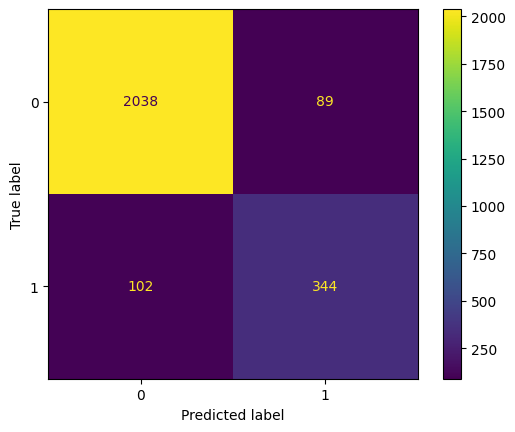

In [47]:
ConfusionMatrixDisplay.from_estimator(best_pipe_xgb,X_test, y_test)

In [48]:
joblib.dump(best_pipe_xgb, MODELS_DIR / "xgb_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\xgb_model.joblib']

In [50]:
with open(MODELS_DIR / "xgb_model_params.json", "w") as f:
    json.dump(grid_search_xgb.best_params_, f, indent=4)

## Skrub + random forest

In [51]:
warnings.filterwarnings('ignore')
rfc_model = RandomForestClassifier(
    class_weight='balanced' # Hace balanceo de clases
)

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("classifier", rfc_model)
])

# This is the list of hyperparameters to tune
param_distributions = {
    'classifier__n_estimators': randint(50, 500),
    'classifier__max_depth': randint(3, 15),
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(1, 20),
    'classifier__max_features': ['auto', 'sqrt', 'log2', None],
    'classifier__bootstrap': [True, False],
    'classifier__criterion': ['gini', 'entropy', 'log_loss']
}

grid_search_rfc = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=50,
                                 scoring='f1_weighted'
                                 )
grid_search_rfc.fit(X_train,
                y_train,
                
                )

test_score = f1_score(y_test, grid_search_rfc.predict(X_test), average='weighted')
print(f'Best score: {grid_search_rfc.best_score_:.3f} with {grid_search_rfc.best_params_}')
print(f'Test score: {test_score:.3f}')

Best score: 0.911 with {'classifier__bootstrap': True, 'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 17, 'classifier__n_estimators': 107}
Test score: 0.910


In [52]:
best_pipe_rfc = grid_search_rfc.best_estimator_

y_pred = best_pipe_rfc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.953     0.935     0.944      2127
           1      0.715     0.783     0.747       446

    accuracy                          0.908      2573
   macro avg      0.834     0.859     0.846      2573
weighted avg      0.912     0.908     0.910      2573



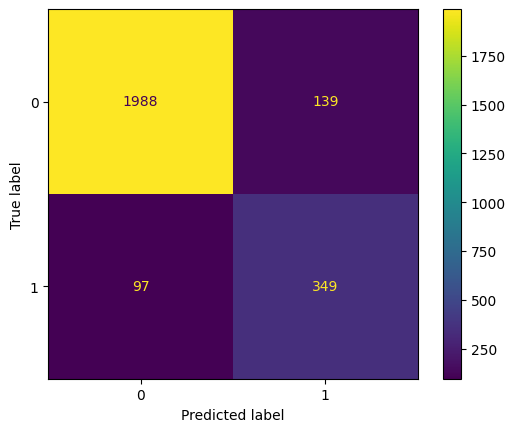

In [53]:
ConfusionMatrixDisplay.from_estimator(best_pipe_rfc,X_test, y_test)

In [54]:
joblib.dump(best_pipe_rfc, MODELS_DIR / "rfc_model.joblib")

['C:\\Users\\jhquiza\\repos\\proyecto-riesgos\\default\\models\\rfc_model.joblib']

In [55]:
with open(MODELS_DIR / "rfc_model_params.json", "w") as f:
    json.dump(grid_search_rfc.best_params_, f, indent=4)

## Skrub + logistic regresion

In [56]:
warnings.filterwarnings('ignore')

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("scaler", StandardScaler(with_mean=False)),  # StandardScaler para datos dispersos
    ("classifier", LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced'))
])

# This is the list of hyperparameters to tune
param_distributions = {
    'classifier__penalty':['l1', 'l2'], 
    'classifier__C':loguniform(1e-3, 1e3)   
}

grid_search_lrc = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=50,
                                 scoring='f1_weighted'
                                 )
grid_search_lrc.fit(
    X_train,
    y_train
    )

test_score = f1_score(y_test, grid_search_lrc.predict(X_test), average='weighted')
print(f'Best score: {grid_search_lrc.best_score_:.3f} with {grid_search_lrc.best_params_}')
print(f'Test score: {test_score:.3f}')

KeyboardInterrupt: 

In [40]:
best_pipe_lrc = grid_search_lrc.best_estimator_
y_pred = best_pipe_lrc.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.957     0.816     0.881      2148
           1      0.467     0.816     0.594       425

    accuracy                          0.816      2573
   macro avg      0.712     0.816     0.738      2573
weighted avg      0.876     0.816     0.833      2573



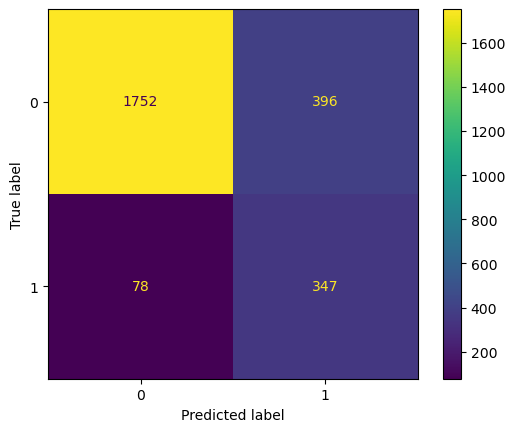

In [41]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc,X_test, y_test)

In [42]:
joblib.dump(best_pipe_lrc, "best_pipe_lrc.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_lrc.joblib']

## Skrub + logistic regresor classifier + balance de clases

In [43]:
warnings.filterwarnings('ignore')

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = ImbPipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("scaler", StandardScaler(with_mean=False)),  # StandardScaler para datos dispersos
    ('undersampling', RandomUnderSampler(sampling_strategy='majority', random_state=1)),
    ("classifier", LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced'))
])

# This is the list of hyperparameters to tune
param_distributions = {
    'classifier__penalty':['l1', 'l2'], 
    'classifier__C':loguniform(1e-3, 1e3)   
}

grid_search_lrc_bal = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=50,
                                 scoring='f1_weighted'
                                 )
grid_search_lrc_bal.fit(X_train,
                y_train,
                
                )

test_score = f1_score(y_test, grid_search_lrc_bal.predict(X_test), average='weighted')
print(f'Best score: {grid_search_lrc_bal.best_score_:.3f} with {grid_search_lrc_bal.best_params_}')
print(f'Test score: {test_score:.3f}')

Best score: 0.835 with {'classifier__C': np.float64(12.496206021055345), 'classifier__penalty': 'l1'}
Test score: 0.827


In [44]:
best_pipe_lrc_bal = grid_search_lrc_bal.best_estimator_
y_pred = best_pipe_lrc_bal.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.959     0.804     0.875      2148
           1      0.455     0.828     0.587       425

    accuracy                          0.808      2573
   macro avg      0.707     0.816     0.731      2573
weighted avg      0.876     0.808     0.827      2573



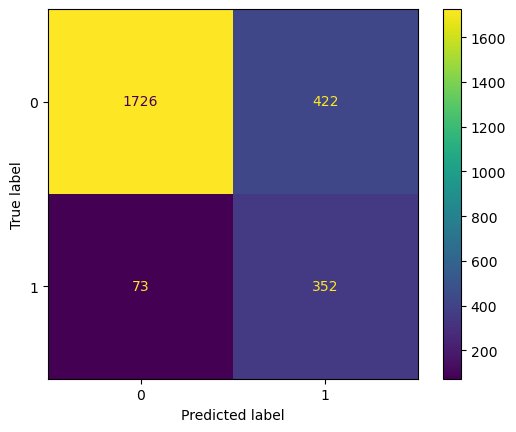

In [45]:
ConfusionMatrixDisplay.from_estimator(best_pipe_lrc_bal,X_test, y_test)

In [46]:
joblib.dump(best_pipe_lrc_bal, "best_pipe_lrc_bal.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_lrc_bal.joblib']

## Skrub + Multilayer Perceptron

In [47]:
warnings.filterwarnings('ignore')

# This is the pipeline with TableVectorizer and XGBClassifier
pipe = Pipeline([
    ("prep", TableVectorizer()),  # detecta y transforma numéricos/categóricos
    ("scaler", StandardScaler(with_mean=False)),  # StandardScaler para datos dispersos
    ("classifier", MLPClassifier(learning_rate_init=0.001, hidden_layer_sizes=[10], activation='logistic'))
])

# This is the list of hyperparameters to tune
param_distributions = {
    'classifier__max_iter': [1000], 
    'classifier__alpha': 10.0 ** -np.arange(-3,2), 
    'classifier__learning_rate_init': loguniform(0.001, 0.1),
    'classifier__hidden_layer_sizes':[(10,5),(20,10),(20,),(50,20),(100,20),(100,)],
    'classifier__activation': ['logistic', 'tanh', 'relu'],
    
}

grid_search_mlp = RandomizedSearchCV(estimator=pipe,
                                 param_distributions=param_distributions,
                                 n_iter=50,
                                 scoring='f1_weighted'
                                 )
grid_search_mlp.fit(X_train,
                y_train,
                
                )

test_score = f1_score(y_test, grid_search_mlp.predict(X_test), average='weighted')
print(f'Best score: {grid_search_mlp.best_score_:.3f} with {grid_search_mlp.best_params_}')
print(f'Test score: {test_score:.3f}')

Best score: 0.888 with {'classifier__activation': 'relu', 'classifier__alpha': np.float64(0.1), 'classifier__hidden_layer_sizes': (20,), 'classifier__learning_rate_init': np.float64(0.001759902574649333), 'classifier__max_iter': 1000}
Test score: 0.879


In [48]:
best_pipe_mlp = grid_search_mlp.best_estimator_
y_pred = best_pipe_mlp.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.907     0.965     0.935      2148
           1      0.739     0.499     0.596       425

    accuracy                          0.888      2573
   macro avg      0.823     0.732     0.765      2573
weighted avg      0.879     0.888     0.879      2573



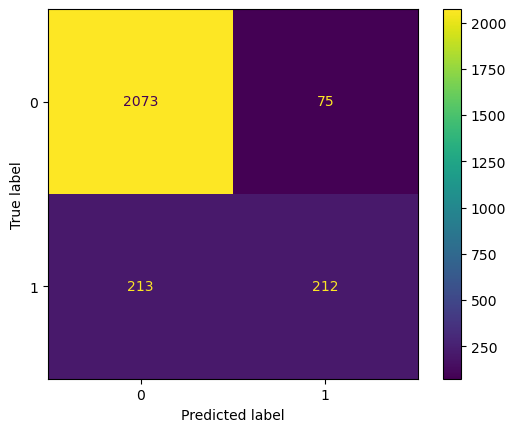

In [49]:
ConfusionMatrixDisplay.from_estimator(best_pipe_mlp,X_test, y_test)

In [50]:
joblib.dump(best_pipe_mlp, "best_pipe_mlp.joblib")
# best_skrub=joblib.load("best_skrub_model.joblib")

['best_pipe_mlp.joblib']

# ROC and Precision-Recall curves for models

In [19]:
best_lrc=joblib.load("best_pipe_lrc.joblib")
best_mlp=joblib.load("best_pipe_mlp.joblib")
best_rfc=joblib.load("best_pipe_rfc.joblib")
best_hist=joblib.load("best_pipe_hist.joblib")
best_lgb=joblib.load("best_pipe_lgb.joblib")
best_xgb=joblib.load("best_pipe_xgb.joblib")

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1804, number of negative: 8484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005629 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10752
[LightGBM] [Info] Number of data points in the train set: 10288, number of used features: 82
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175350 -> initscore=-1.548176
[LightGBM] [Info] Start training from score -1.548176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

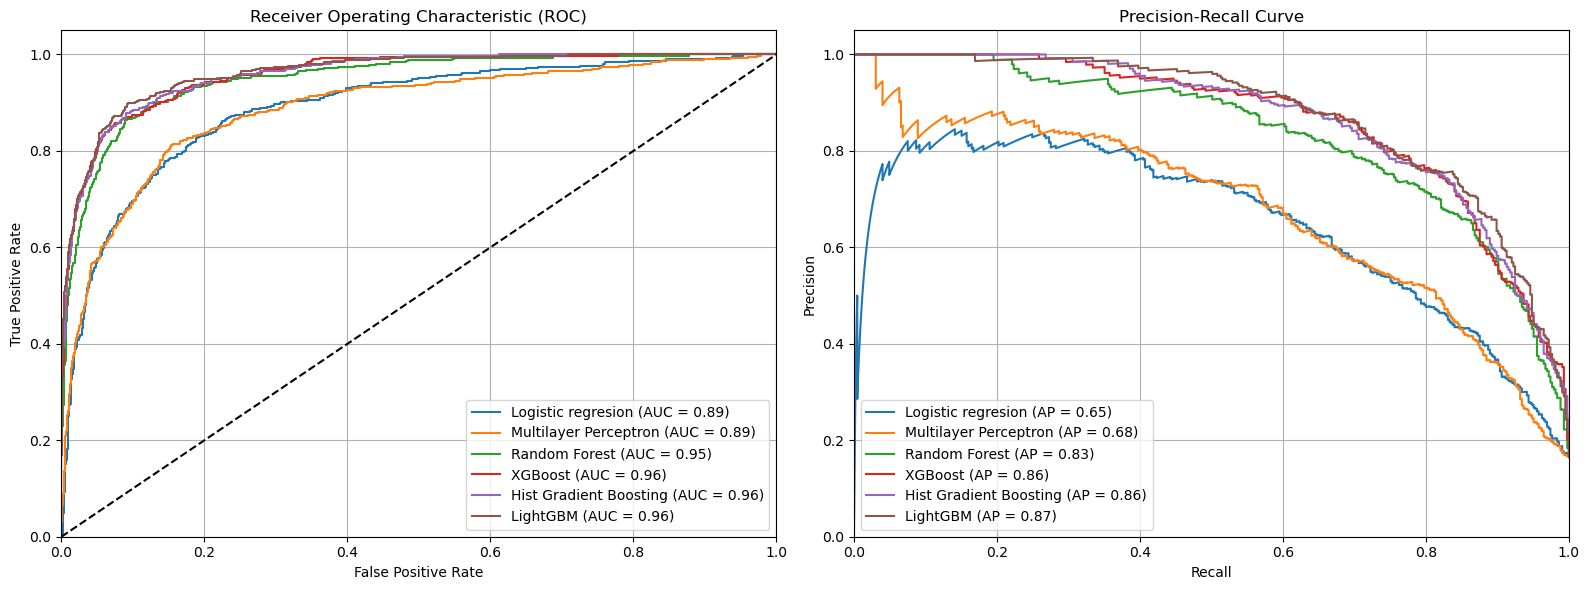

In [54]:
def plot_roc_pr_curves(models, model_names, X_train, X_test, y_train, y_test):
    plt.figure(figsize=(16, 6))
    
    # Create subplots
    ax1 = plt.subplot(1, 2, 1)  # ROC curve
    ax2 = plt.subplot(1, 2, 2)  # Precision-Recall curve
    
    # Iterate through models
    for model, name in zip(models, model_names):
        # Train model
        model.fit(X_train, y_train)
        
        # Get probabilities
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
        
        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        ax2.plot(recall, precision, label=f'{name} (AP = {pr_auc:.2f})')
    
    # ROC Curve formatting
    ax1.plot([0, 1], [0, 1], 'k--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic (ROC)')
    ax1.legend(loc="lower right")
    ax1.grid(True)
    
    # Precision-Recall Curve formatting
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc="lower left")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('roc_pr_curves.png', dpi=300)
    plt.show()

# Define your models and data
models = [best_lrc, best_mlp, best_rfc, best_xgb, best_hist, best_lgb]
model_names = ["Logistic regresion", "Multilayer Perceptron", "Random Forest", "XGBoost", "Hist Gradient Boosting", "LightGBM"]
training_datasets = X_train
test_datasets = X_test

# Call the function
plot_roc_pr_curves(models, model_names, training_datasets, test_datasets, y_train, y_test)

# Model calibration


Logistic Regression Classification Metrics:
              precision    recall  f1-score   support

 Non-default       0.88      0.99      0.93      2148
     Default       0.81      0.29      0.43       425

    accuracy                           0.87      2573
   macro avg       0.84      0.64      0.68      2573
weighted avg       0.86      0.87      0.84      2573


Multilayer Perceptron Classification Metrics:
              precision    recall  f1-score   support

 Non-default       0.90      0.97      0.93      2148
     Default       0.75      0.47      0.58       425

    accuracy                           0.89      2573
   macro avg       0.82      0.72      0.76      2573
weighted avg       0.88      0.89      0.88      2573


Random Forest Classification Metrics:
              precision    recall  f1-score   support

 Non-default       0.94      0.96      0.95      2148
     Default       0.79      0.70      0.74       425

    accuracy                           0.92      25

ValueError: num must be an integer with 1 <= num <= 10, not 11

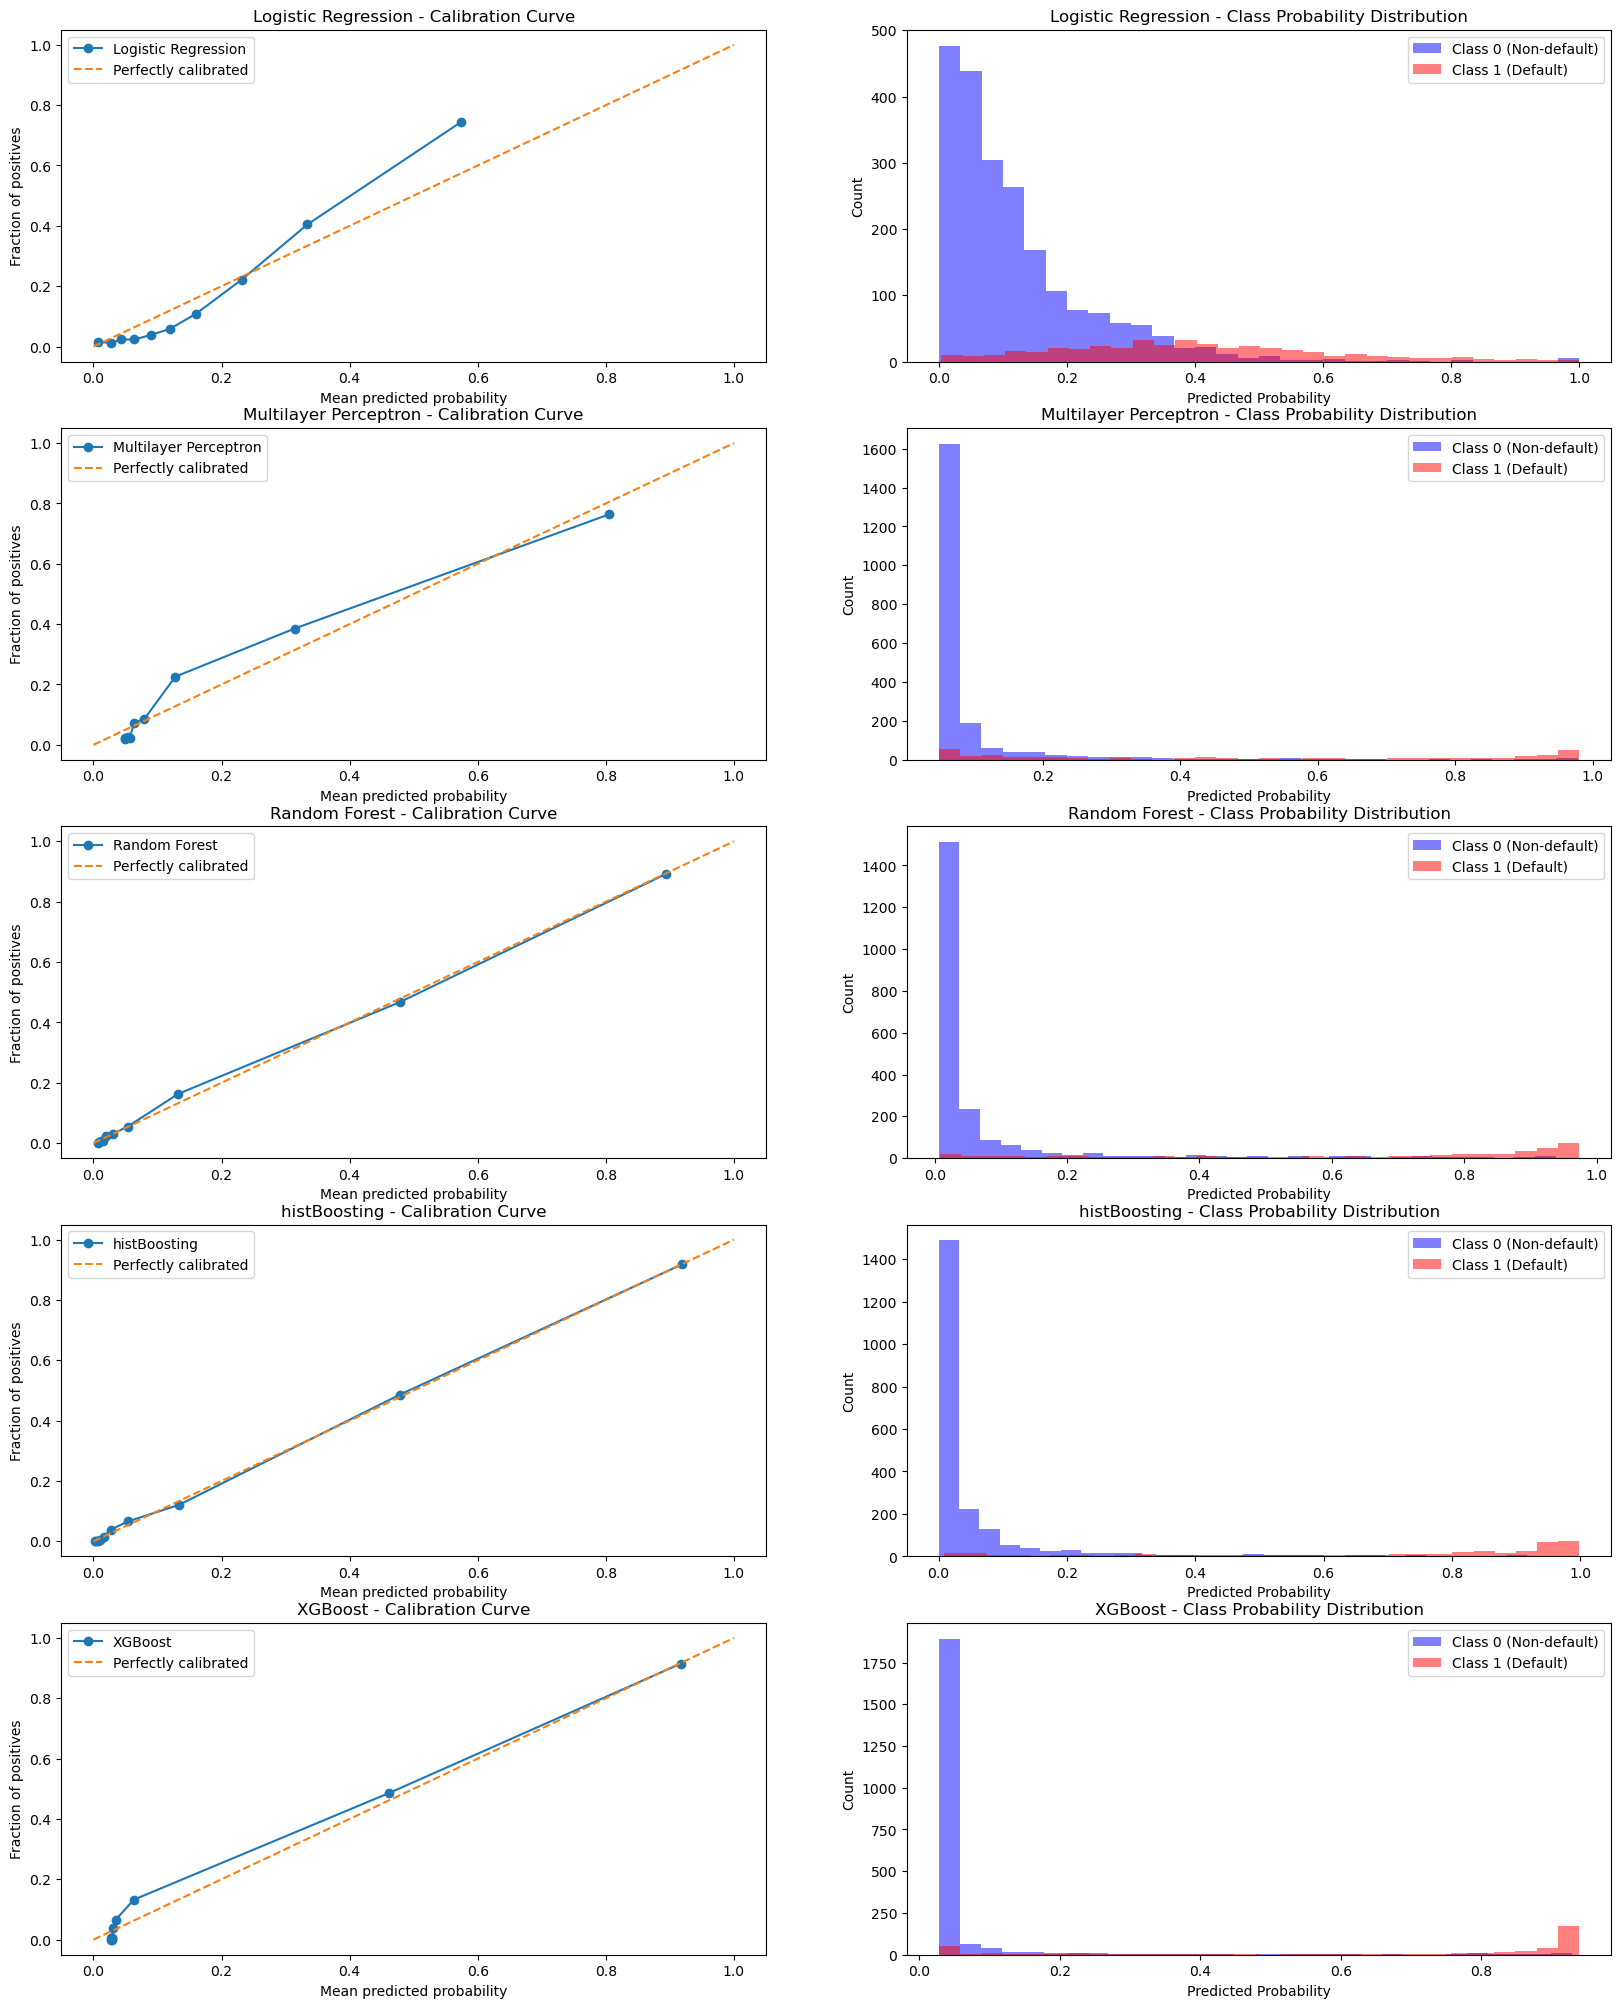

In [55]:
models = {
    'Logistic Regression': best_lrc,
    'Multilayer Perceptron': best_mlp,
    'Random Forest': best_rfc,
    'histBoosting': best_hist,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb
}


plt.figure(figsize=(20, 25))

# Iterar sobre cada modelo
for i, (model_name, model) in enumerate(models.items(), 1):
    # --- Calibración ---
    calibrated_clf = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')
    calibrated_clf.fit(X_test, y_test)
    
    # Predicciones calibradas
    y_pred_calib = calibrated_clf.predict(X_test)
    y_proba_calib = calibrated_clf.predict_proba(X_test)[:, 1]
    
    # --- Gráficas de Calibración ---
    plt.subplot(5, 2, 2*i-1)
    prob_true, prob_pred = calibration_curve(y_test, y_proba_calib, n_bins=10, strategy='quantile')
    plt.plot(prob_pred, prob_true, marker='o', label=model_name)
    plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"{model_name} - Calibration Curve")
    plt.legend()
    
    plt.subplot(5, 2, 2*i)
    plt.hist(y_proba_calib[y_test == 0], bins=30, alpha=0.5, label='Class 0 (Non-default)', color='blue')
    plt.hist(y_proba_calib[y_test == 1], bins=30, alpha=0.5, label='Class 1 (Default)', color='red')
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(f"{model_name} - Class Probability Distribution")
    plt.legend()
    
    # --- Métricas y Disparate Impact ---
    print(f"\n{model_name} Classification Metrics:")
    print(classification_report(y_test, y_pred_calib, target_names=['Non-default', 'Default']))
    
    # Métricas estándar
    #metrics = {
     #  "Precision": precision_score(y_test, y_pred_calib),
     #   "Recall": recall_score(y_test, y_pred_calib),
     #   "F1-Score": f1_score(y_test, y_pred_calib)
    #}
    
    #for metric, value in metrics.items():
    #    print(f"{metric}: {value:.4f}")
    
    
plt.tight_layout()
plt.show()

# 4. Bias in ML algorithms


### Impacto dispar

Para este caso del impacto dispar, debemos tener en cuenta que nuestros éxitos están definidos por las personas que no caigan en default, es decir, el hecho de que no se caiga en default genera ganancias para la entidad (default = 0). En este caso la formula estaría dada por:

$$DI = \frac{P(Y=0 | S=0)}{P(Y=0 | S=1)}$$



In [20]:
from FinalBiasAnalysis_compBWAF import cptDI

In [ ]:
vectorizer = best_lgb.named_steps['prep']
X_test_vectorized = vectorizer.transform(X_test)

In [22]:
np.unique(X_test_vectorized['intestrato'])

array([1., 2., 3., 4., 5., 6.], dtype=float32)

In [23]:
X_test_col_names = list(X_test.columns)
X_test_values = X_test.values
y_test_values = y_test.values.reshape(-1,1)

Para la variable sexo:

In [24]:
sex_ = X_test_values[:,X_test_col_names.index('sexo')].ravel()
DI_sex = cptDI(sex_, y_test_values.ravel())
print("Disparate Impact = " + str(DI_sex))

#y_test_pred_skrub = best_skrub.predict(X_test)
#DI = cptDI(sex_, y_test_pred_skrub.ravel()) # XGB
#print('DI y_test_pred_xgb =', DI)

y_test_pred_lrc = best_lrc.predict(X_test)
DI = cptDI(sex_, y_test_pred_lrc.ravel()) # XGB
print('DI y_test_pred_lrc =', DI)

y_test_pred_mlp = best_mlp.predict(X_test)
DI = cptDI(sex_, y_test_pred_mlp.ravel()) # XGB
print('DI y_test_pred_mlp =', DI)

y_test_pred_rfc = best_rfc.predict(X_test)
DI = cptDI(sex_, y_test_pred_rfc.ravel()) # XGB
print('DI y_test_pred_rfc =', DI)

y_test_pred_xgb = best_xgb.predict(X_test)
DI = cptDI(sex_, y_test_pred_xgb.ravel()) # XGB
print('DI y_test_pred_xgb =', DI)

y_test_pred_hist = best_hist.predict(X_test)
DI = cptDI(sex_, y_test_pred_hist.ravel()) # XGB
print('DI y_test_pred_hist =', DI)

y_test_pred_lgb = best_lgb.predict(X_test)
DI = cptDI(sex_, y_test_pred_lgb.ravel()) # XGB
print('DI y_test_pred_lgb =', DI)

Disparate Impact = 0.9574059154274301
DI y_test_pred_lrc = 0.8930006654857242
DI y_test_pred_mlp = 0.921564334174303
DI y_test_pred_rfc = 0.9409296778498714
DI y_test_pred_xgb = 0.9383961880636392
DI y_test_pred_hist = 0.9432526926035828
[LightGBM] [Warning] Unknown parameter: eg_alpha
DI y_test_pred_lgb = 0.9342327851576583


The function cptDI is only available for binary variables:

In [25]:
X_test_temp = X_test.copy()
selection=1
X_test_temp.loc[X_test_temp['intestrato'] != selection, 'intestrato'] = 0
X_test_temp.loc[X_test_temp['intestrato'] == selection, 'intestrato'] = 1
# (Opcional) forzar tipo entero y mostrar conteo de valores
X_test_temp['intestrato'] = X_test_temp['intestrato'].astype(int)
X_test_values = X_test_temp.values

Para la variable estrato = 1

In [26]:
estrato_ = X_test_values[:,X_test_col_names.index('intestrato')].ravel()
DI_estrato = cptDI(estrato_, y_test_values.ravel())
print("Disparate Impact = " + str(DI_estrato))

#y_test_pred_skrub = best_skrub.predict(X_test)
#DI = cptDI(estrato_, y_test_pred_skrub.ravel()) # XGB
#print('DI y_test_pred_xgb =', DI)

y_test_pred_lrc = best_lrc.predict(X_test)
DI = cptDI(estrato_, y_test_pred_lrc.ravel()) # XGB
print('DI y_test_pred_lrc =', DI)

y_test_pred_mlp = best_mlp.predict(X_test)
DI = cptDI(estrato_, y_test_pred_mlp.ravel()) # XGB
print('DI y_test_pred_mlp =', DI)

y_test_pred_rfc = best_rfc.predict(X_test)
DI = cptDI(estrato_, y_test_pred_rfc.ravel()) # XGB
print('DI y_test_pred_rfc =', DI)

y_test_pred_xgb = best_xgb.predict(X_test)
DI = cptDI(estrato_, y_test_pred_xgb.ravel()) # XGB
print('DI y_test_pred_xgb =', DI)

y_test_pred_hist = best_hist.predict(X_test)
DI = cptDI(estrato_, y_test_pred_hist.ravel()) # XGB
print('DI y_test_pred_hist =', DI)

y_test_pred_lgb = best_lgb.predict(X_test)
DI = cptDI(estrato_, y_test_pred_lgb.ravel()) # XGB
print('DI y_test_pred_lgb =', DI)

Disparate Impact = 1.0487375502801504
DI y_test_pred_lrc = 1.050952074545411
DI y_test_pred_mlp = 1.0281875461573697
DI y_test_pred_rfc = 1.0582182947463994
DI y_test_pred_xgb = 1.0662076861505414
DI y_test_pred_hist = 1.056233203941475
[LightGBM] [Warning] Unknown parameter: eg_alpha
DI y_test_pred_lgb = 1.0535462492949803


We are going to analize only the variable sex becouse is binary:

In [29]:
X_train_col_names = list(X_train.columns)
X_train_values = X_train.values
y_train_values = y_train.values.reshape(-1,1)

In [30]:
from FinalBiasAnalysis_compBWAF import Clf_with_ClassSpecDecRules
from FinalBiasAnalysis_compBWAF import Clf_with_AdaptiveThreshForS0
from FinalBiasAnalysis_compBWAF import Make_Kfold_boxplots

In [31]:
X_train.shape

(10288, 23)

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1504, number of negative: 7069
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10413
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175435 -> initscore=-1.547591
[LightGBM] [Info] Start training from score -1.547591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 926, number of negative: 3646
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002586 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8586
[LightGBM] [Info] Number of data points in the train set: 4572, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.202537 -> initscore=-1.370512
[LightGBM] [Info] Start training from score -1.370512
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 578, number of negative: 3423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8274
[LightGBM] [Info] Number of data points in the train set: 4001, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.144464 -> initscore=-1.778699
[LightGBM] [Info] Start training from score -1.778699
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1504, number of negative: 7069
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10370
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175435 -> initscore=-1.547591
[LightGBM] [Info] Start training from score -1.547591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1516, number of negative: 7057
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10334
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176834 -> initscore=-1.537945
[LightGBM] [Info] Start training from score -1.537945
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 960, number of negative: 3649
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002619 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8575
[LightGBM] [Info] Number of data points in the train set: 4609, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.208288 -> initscore=-1.335275
[LightGBM] [Info] Start training from score -1.335275
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 556, number of negative: 3408
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8182
[LightGBM] [Info] Number of data points in the train set: 3964, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.140262 -> initscore=-1.813113
[LightGBM] [Info] Start training from score -1.813113
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1516, number of negative: 7057
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10377
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176834 -> initscore=-1.537945
[LightGBM] [Info] Start training from score -1.537945
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1491, number of negative: 7082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10489
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.173918 -> initscore=-1.558109
[LightGBM] [Info] Start training from score -1.558109
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 924, number of negative: 3652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8769
[LightGBM] [Info] Number of data points in the train set: 4576, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.201923 -> initscore=-1.374318
[LightGBM] [Info] Start training from score -1.374318
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 567, number of negative: 3430
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8122
[LightGBM] [Info] Number of data points in the train set: 3997, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.141856 -> initscore=-1.799956
[LightGBM] [Info] Start training from score -1.799956
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1491, number of negative: 7082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10533
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.173918 -> initscore=-1.558109
[LightGBM] [Info] Start training from score -1.558109
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1515, number of negative: 7058
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10385
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176718 -> initscore=-1.538746
[LightGBM] [Info] Start training from score -1.538746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 951, number of negative: 3684
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8672
[LightGBM] [Info] Number of data points in the train set: 4635, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205178 -> initscore=-1.354240
[LightGBM] [Info] Start training from score -1.354240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 564, number of negative: 3374
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8194
[LightGBM] [Info] Number of data points in the train set: 3938, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143220 -> initscore=-1.788800
[LightGBM] [Info] Start training from score -1.788800
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting'

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1515, number of negative: 7058
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003833 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10410
[LightGBM] [Info] Number of data points in the train set: 8573, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176718 -> initscore=-1.538746
[LightGBM] [Info] Start training from score -1.538746
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1486, number of negative: 7088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10377
[LightGBM] [Info] Number of data points in the train set: 8574, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.173315 -> initscore=-1.562315
[LightGBM] [Info] Start training from score -1.562315
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 929, number of negative: 3699
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8673
[LightGBM] [Info] Number of data points in the train set: 4628, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200735 -> initscore=-1.381709
[LightGBM] [Info] Start training from score -1.381709
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 557, number of negative: 3389
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8150
[LightGBM] [Info] Number of data points in the train set: 3946, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.141156 -> initscore=-1.805725
[LightGBM] [Info] Start training from score -1.805725
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting'

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1486, number of negative: 7088
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10356
[LightGBM] [Info] Number of data points in the train set: 8574, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.173315 -> initscore=-1.562315
[LightGBM] [Info] Start training from score -1.562315
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please co

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1508, number of negative: 7066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10392
[LightGBM] [Info] Number of data points in the train set: 8574, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175881 -> initscore=-1.544510
[LightGBM] [Info] Start training from score -1.544510
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 925, number of negative: 3675
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8649
[LightGBM] [Info] Number of data points in the train set: 4600, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.201087 -> initscore=-1.379515
[LightGBM] [Info] Start training from score -1.379515
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 583, number of negative: 3391
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8012
[LightGBM] [Info] Number of data points in the train set: 3974, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.146704 -> initscore=-1.760693
[LightGBM] [Info] Start training from score -1.760693
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown c

[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Warning] Unknown parameter: eg_alpha
[LightGBM] [Info] Number of positive: 1508, number of negative: 7066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10445
[LightGBM] [Info] Number of data points in the train set: 8574, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175881 -> initscore=-1.544510
[LightGBM] [Info] Start training from score -1.544510
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_check_input.py:175: UserWarning: Only pandas and polars DataFrames are supported, but input is a Numpy array. Please convert Numpy arrays to DataFrames before passing them to skrub transformers. Converting to pandas DataFrame with columns ['0', '1', …].
  warnings.warn(
c:\Users\andresorozco\AppData\Local\anaconda3\envs\ml_tabular\lib\site-packages\skrub\_clean_null_strings.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return col.replace(r"^\s*$", "", regex=True)


[LightGBM] [Warning] Unknown parameter: eg_alpha


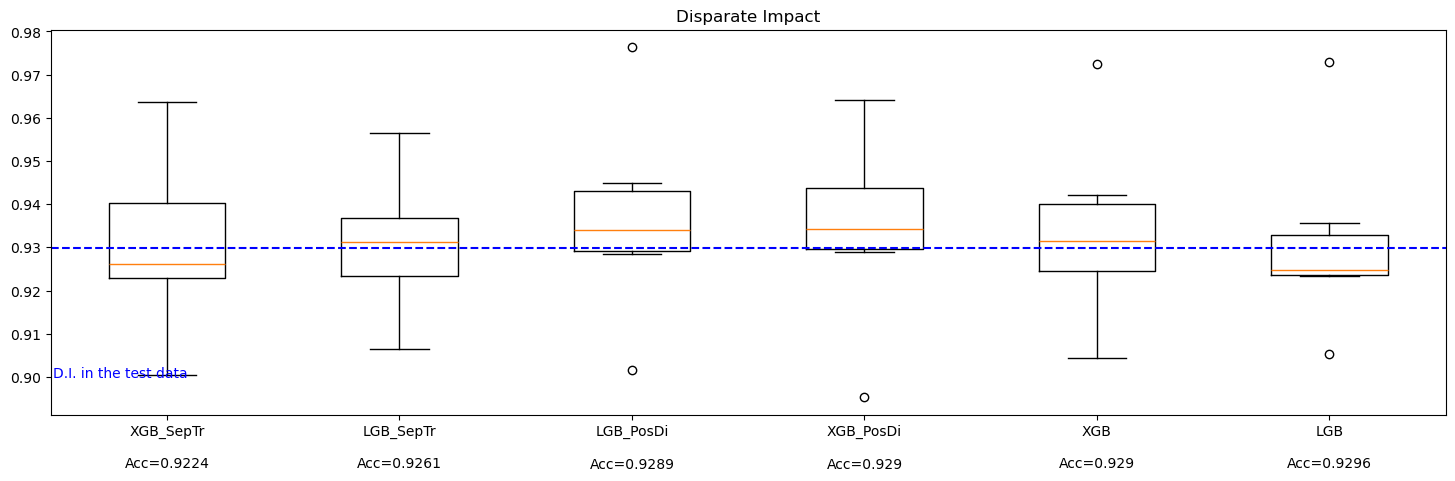

c:\Users\andresorozco\Documents\Python\DeepLearning\notebook_info_v2\notebook_info_v2\Notebook Superfinanciera\FinalBiasAnalysis_compBWAF.py:186: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(lst_tnr[i], lst_tpr[i], alpha=0.5,c=listColors[i], marker=listMarkers[i], s=100., label=list_classifierNames[i], edgecolors='none')
c:\Users\andresorozco\Documents\Python\DeepLearning\notebook_info_v2\notebook_info_v2\Notebook Superfinanciera\FinalBiasAnalysis_compBWAF.py:199: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(lst_tnr_S0[i], lst_tpr_S0[i], alpha=0.5,c=listColors[i], marker=listMarkers[i], s=100., label=list_classifierNames[i], edgecolors='none')
c:\Users\andresorozco\Docu

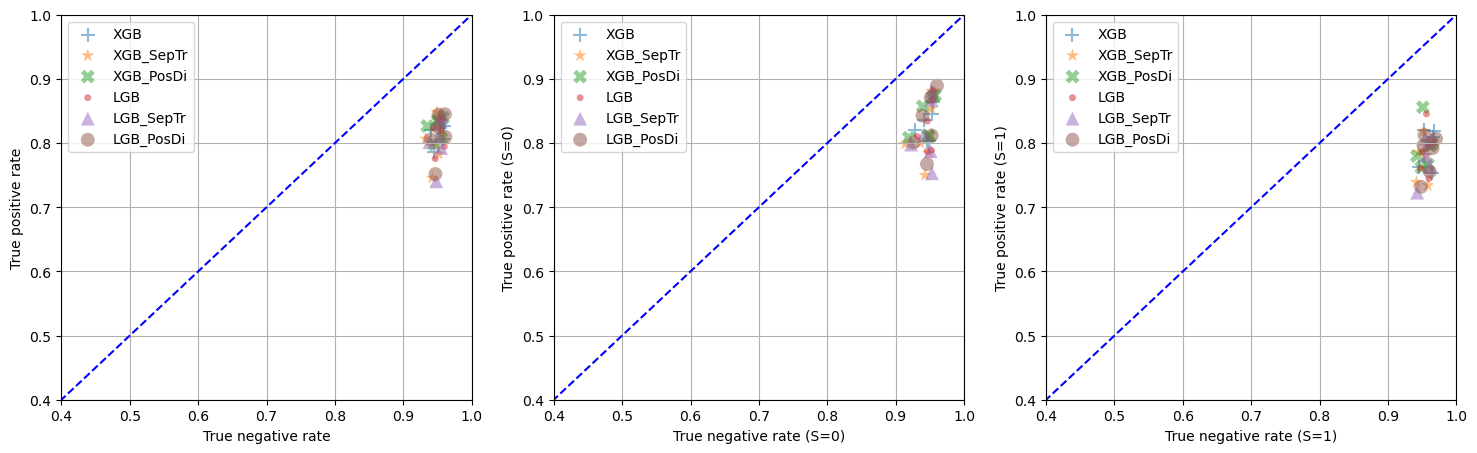

Average rates XGB:
 -> True positive (all/S=0/S=1): 0.82 0.83 0.79
 -> True negative (all/S=0/S=1): 0.95 0.95 0.96
Average rates XGB_SepTr:
 -> True positive (all/S=0/S=1): 0.8 0.81 0.78
 -> True negative (all/S=0/S=1): 0.95 0.94 0.95
Average rates XGB_PosDi:
 -> True positive (all/S=0/S=1): 0.82 0.84 0.79
 -> True negative (all/S=0/S=1): 0.95 0.94 0.95
Average rates LGB:
 -> True positive (all/S=0/S=1): 0.82 0.83 0.79
 -> True negative (all/S=0/S=1): 0.95 0.95 0.96
Average rates LGB_SepTr:
 -> True positive (all/S=0/S=1): 0.8 0.82 0.78
 -> True negative (all/S=0/S=1): 0.95 0.95 0.96
Average rates LGB_PosDi:
 -> True positive (all/S=0/S=1): 0.81 0.83 0.78
 -> True negative (all/S=0/S=1): 0.95 0.95 0.96


In [32]:
sex = X_train_values[:, X_train_col_names.index('sexo')]


#clf_LGB_CS=Clf_with_ClassSpecDecRules(best_skrub,X_test_col_names.index('sexo'),ReturnBestPred=False)
#clf_LGB_AdapThresh=Clf_with_AdaptiveThreshForS0(best_skrub,X_test_col_names.index('sexo'))

#clf_LR_CS=Clf_with_ClassSpecDecRules(best_lrc,X_test_col_names.index('sexo'),ReturnBestPred=False)
#clf_LR_AdapThresh=Clf_with_AdaptiveThreshForS0(lr_model,X_test_col_names.index('sexo'))

clf_RF_CS=Clf_with_ClassSpecDecRules(best_rfc,X_train_col_names.index('sexo'),ReturnBestPred=False)
clf_RF_AdapThresh=Clf_with_AdaptiveThreshForS0(best_rfc,X_train_col_names.index('sexo'))

clf_XGB_CS=Clf_with_ClassSpecDecRules(best_xgb,X_train_col_names.index('sexo'),ReturnBestPred=False)
clf_XGB_AdapThresh=Clf_with_AdaptiveThreshForS0(best_xgb,X_train_col_names.index('sexo'))

clf_HIST_CS=Clf_with_ClassSpecDecRules(best_hist,X_train_col_names.index('sexo'),ReturnBestPred=False)
clf_HIST_AdapThresh=Clf_with_AdaptiveThreshForS0(best_hist,X_train_col_names.index('sexo'))

clf_LGB_CS=Clf_with_ClassSpecDecRules(best_lgb,X_train_col_names.index('sexo'),ReturnBestPred=False)
clf_LGB_AdapThresh=Clf_with_AdaptiveThreshForS0(best_lgb,X_train_col_names.index('sexo'))

list_classifiers=[#best_lrc,clf_LR_CS,clf_LR_AdapThresh,
                #  best_rfc,clf_RF_CS,clf_RF_AdapThresh,
                  best_xgb,clf_XGB_CS,clf_XGB_AdapThresh,
                #  best_hist,clf_HIST_CS,clf_HIST_AdapThresh,
                  best_lgb,clf_LGB_CS,clf_LGB_AdapThresh]

list_classifierNames=[#'LR','LR_SepTr','LR_PosDi',
                 #     'RF','RF_SepTr','RF_PosDi',
                      'XGB','XGB_SepTr','XGB_PosDi',
                  #    'HIST','HIST_SepTr','HIST_PosDi',
                      'LGB','LGB_SepTr','LGB_PosDi'
                      ]


nsplits=6

PreFigNam='Summary'
Make_Kfold_boxplots(list_classifiers, list_classifierNames, sex, 
                    X_train_values, y_train_values, nsplits, Show_DI_boxPlotsOnly=True, PrefixFigNames=PreFigNam)

# Equality of Odds:

In [ ]:
from matplotlib.patches import Wedge

In [ ]:
def Cpt_EoO(S,Y_pred,Y_true,w=1 ,alpha=0.05, boxplot=False, wedge=False):
    '''
    Calculate the Equality of Odds index and possibly return the wanted visualisation
    input:
        S: sensible variable
        Y_pred: predicted class
        Y_true: true value to predict
        w: if given, np.array containing the weight given to each observation
        1-alpha: quartile for the desired confidence interval
        boxplot/wedge: Optionally represent a boxplot and/or a wedge of the DI or the EoO
    output:
        Exact value and confidence interval of the EoO
    '''
 
    n=S.shape[0]
 
    assert 0<alpha<2, 'alpha is the argument signifying the quartile, please let it be strictly between 0 and 2'
    assert n==Y_pred.shape[0],'every data must have the same length'
 
    if type(w) == int:
        Z = np.array([np.multiply(1-S,Y_pred),np.multiply(S,Y_pred),1-S,S])
    else:
        Z = np.array([np.multiply(w,np.multiply(1-S,Y_pred)),np.multiply(w,np.multiply(S,Y_pred)),np.multiply(w,1-S),np.multiply(w,S)])
 
    Z_EoO=np.zeros((4,n))
    for i in range (4):
        Z_EoO[i]=np.multiply(Z[i],Y_true)
    return _Asymptotic_behavior(Z_EoO,n,alpha, 'EoO', boxplot, wedge)
 
 
def _Asymptotic_behavior(Z,n,alpha, typ, boxplot, wedge):
    #Covariance matrix and expected value
    E, cov_matrix = _create_cov_matrix_and_esp(Z)
 
    #phi gradient applied to E
    grad_phi_E_T = [E[3]/(E[1]*E[2]) , -(E[0]*E[3])/(E[1]**2*E[2]) , -(E[0]*E[3])/(E[1]*E[2]**2) , E[0]/(E[1]*E[2])]
 
    #confidence interval
    Center, IC = _create_IC(n,E,cov_matrix, grad_phi_E_T, alpha, typ, boxplot, wedge)
    return Center, IC
 
def _create_IC(n,E,cov_matrix, grad_phi_E_T, alpha, typ, boxplot, wedge):
    Center = (E[0]*E[3])/(E[1]*E[2])
    sigma = np.dot(grad_phi_E_T, np.dot(cov_matrix, np.transpose(grad_phi_E_T)))
    norm_quartile = scipy.stats.norm.ppf(1-alpha/2)
    inter = (sigma/n)**(1/2)
    radius = inter*norm_quartile
    IC = [Center-radius, Center+radius]
    if boxplot:
        norm_quartile_25 = scipy.stats.norm.ppf(1-0.5/2)
        radius_25 = inter*norm_quartile_25
        data = [ IC[0],Center-radius_25, Center, Center+radius_25, IC[1] ]
        fig1, ax1 = plt.subplots()
        title = 'Boxplot at ' + str((1 - alpha)*100) +'% confidence interval of ' + typ
        ax1.set_title(title)
        ax1.boxplot(data)
    if wedge:
        _plot_wedge(IC, alpha, typ)
    return Center, IC
 
 
 
def _create_cov_matrix_and_esp(Z):
    E = np.zeros(4)
    cov_diag = np.zeros(4)
    cov_trig = np.zeros((4,4))
    for i in range (4):
        E[i] = np.mean(Z[i])
        cov_diag[i] = np.mean(np.multiply(Z[i],Z[i])) - E[i]**2
        for j in range(i): #must create the triangular sup, if not E won't be learnt yet
            cov_trig[i,j] = np.mean(np.multiply(Z[i],Z[j])) - np.multiply(E[i],E[j])
    return E, np.diag(cov_diag) + cov_trig + np.transpose(cov_trig)
 
 
 
def _plot_wedge(IC, alpha, typ):
    if IC[1]<1:
        plt.rcParams["figure.figsize"] = [5, 3]
    else:
        plt.rcParams["figure.figsize"] = [5, 5]
    fig, ax = plt.subplots()
    theta1, theta2 = IC[0]*180, IC[1]*180
    radius = 1
    center = (0, 0)
    w1 = Wedge(center, radius, 180, 180 - theta2, fc='white', edgecolor='black')
    w2 = Wedge(center, radius, 180 - theta2, 180 - theta1, fc='green', edgecolor='black', alpha=0.3, label="confidence interval of "+typ)
    if IC[1]<1:
        w3 = Wedge(center, radius, 180 - theta1, 180, fc='white', edgecolor='black')
    else:
        w3 = Wedge(center, radius, 180 - theta1, 180, fc='white', edgecolor='black')
    w4 = Wedge(center, radius, 0.2*180-0.3, 0.2*180+0.3, fc='darkred', label = '4/5 recommanded')
    t1 = plt.text(-1, 0, '0')
    t2 = plt.text(-2**(1/2)/2, 2**(1/2)/2, '0.25')
    t3 = plt.text(0, 1, '0.5')
    t4 = plt.text(2**(1/2)/2, 2**(1/2)/2, '0.75')
    t5 = plt.text(1, 0, '1')
    points = plt.scatter([-1, -2**(1/2)/2, 0, 2**(1/2)/2, 1], [0, 2**(1/2)/2, 1, 2**(1/2)/2, 0], color='black')
 
    for wedge in [w1, w2, w3, w4, t1, t2, t3, t4, t5, points]:
        ax.add_artist(wedge)
 
    ax.axis('equal')
    ax.set_xlim(-1.2, 1.2)
    if IC[1]<1:
        ax.set_ylim(-0.2, 1.2)
    else:
        t6 = plt.text(2**(1/2)/2, -2**(1/2)/2, '1.25')
        t7 = plt.text(0, -1, '1.5')
        t8 = plt.text(-2**(1/2)/2, -2**(1/2)/2, '1.75')
        points_2 = plt.scatter([2**(1/2)/2, 0, -2**(1/2)/2], [-2**(1/2)/2, -1, -2**(1/2)/2], color='black')
        for p in [t6, t7, t8, points_2]:
            ax.add_artist(p)
        ax.set_ylim(-1.2, 1.2)
    title = 'Wedge of ' + str((1 - alpha)*100) +'% Confidence about ' + typ +' criteria'
    ax.set_title(title)
    ax.legend()
 
    return fig

In [ ]:
y_pred_test = best_skrub.predict(X_test)

[LightGBM] [Warning] Unknown parameter: eg_alpha


In [ ]:
import scipy

(np.float64(1.0095222810677793),
 [np.float64(0.9143173636402394), np.float64(1.104727198495319)])

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


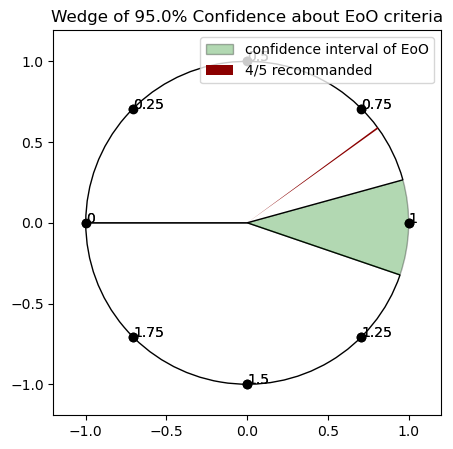

In [ ]:
Cpt_EoO(sex_, y_pred_test, y_test, alpha=0.05, wedge=True)

# SHAP values.

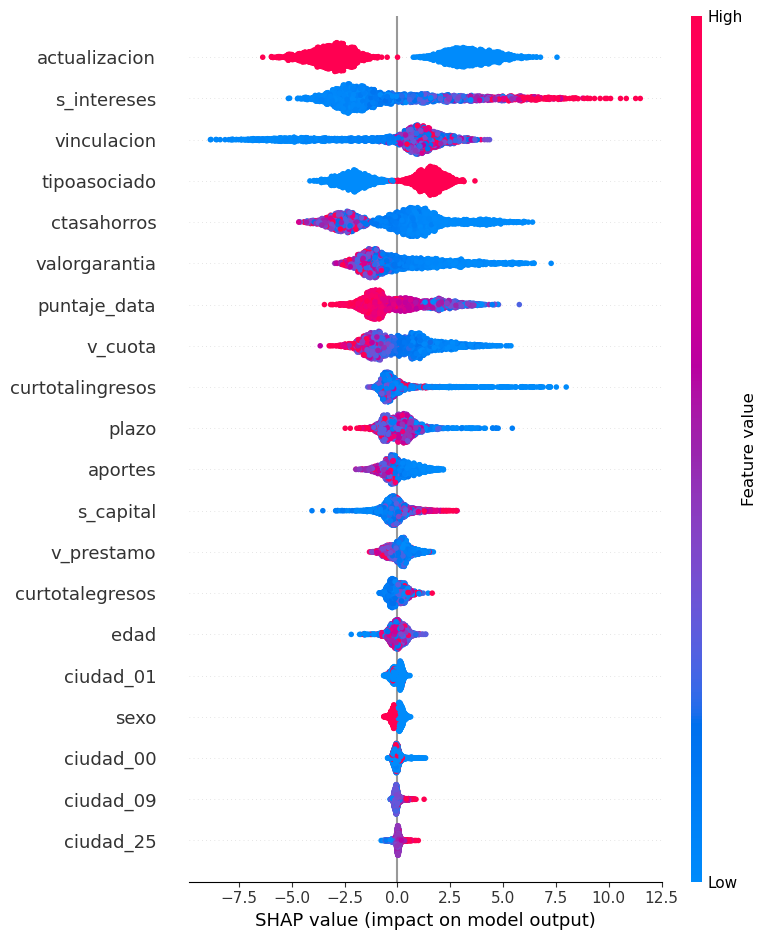

In [ ]:
#Shap no trabaja bien con pipelines, por lo que se transforma el conjunto de prueba usando el pipeline sin el modelo final
X_trans = best_skrub[:-1].transform(X_test)

#Se extrae el modelo del pipeline
model2exp = best_skrub.named_steps["clf"] 

# Crear el objeto explainer (para RandomForestRegressor se recomienda TreeExplainer)
explainer = shap.TreeExplainer(model2exp)

# Calcular los valores SHAP para el conjunto de prueba
shap_values = explainer(X_trans)

# Análisis global
fig = plt.figure()
shap.summary_plot(shap_values, X_trans)
plt.show()

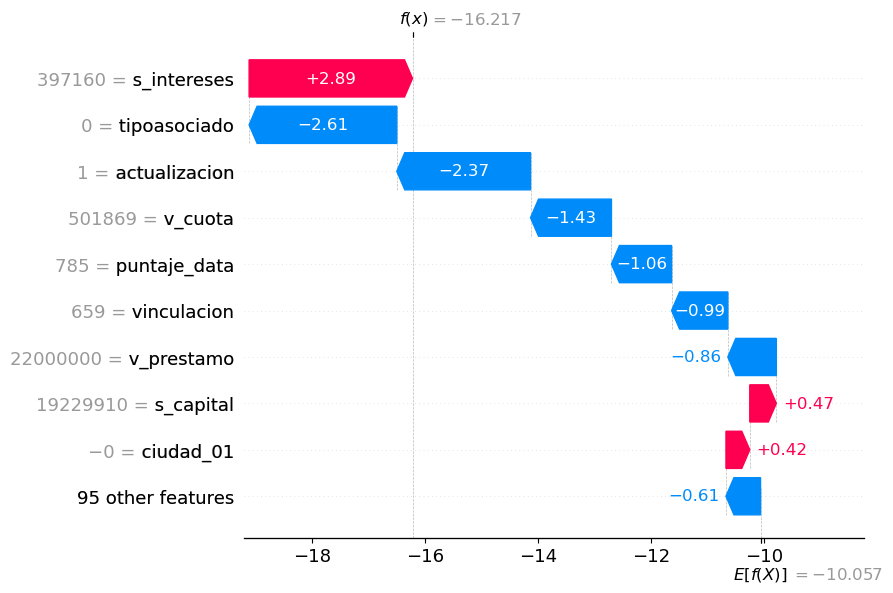

In [ ]:
# Análisis local para una observación específica
fig = plt.figure()
shap.plots.waterfall(shap_values[0])
plt.show();